# Data Tour: Monetary Tightening and U.S. Bank Fragility

This notebook provides an overview of the data used to replicate
Jiang et al. (2024), "Monetary Tightening and U.S. Bank Fragility in 2023:
Mark-to-Market Losses and Uninsured Depositor Runs?"

We work with:
- **WRDS Call Report data**: Quarterly bank balance sheet filings (Q1 2022 snapshot)
- **ETF price data**: iShares Treasury ETFs and MBS ETF (yfinance, 2022-2023)

The MTM loss methodology applies Q1 2022 → Q1 2023 ETF price changes to
each bank's maturity-bucketed asset holdings.

In [1]:
import sys
sys.path.insert(0, "./src/")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from settings import config
import pull_wrds
import pull_etf_data
import clean_data
import calc_mtm_losses

DATA_DIR = Path(config("DATA_DIR"))
OUTPUT_DIR = Path(config("OUTPUT_DIR"))
REPORT_DATE = config("REPORT_DATE")
MTM_END_DATE = config("MTM_END_DATE")

print(f"Report date (balance sheet snapshot): {REPORT_DATE}")
print(f"MTM end date (loss measurement):      {MTM_END_DATE}")

Report date (balance sheet snapshot): 2022-03-31
MTM end date (loss measurement):      2023-03-31


## 1. WRDS Call Report Data

Four data series are pulled from WRDS via SQL:
- **RCON_Series_1**: Domestic balance sheet (RMBS by maturity, first-lien mortgages, deposits)
- **RCON_Series_2**: Domestic treasury securities, other loans, total assets
- **RCFD_Series_1**: Domestic+foreign RMBS, mortgages, other loans
- **RCFD_Series_2**: Domestic+foreign treasury securities, total assets

In [2]:
rcon1 = pull_wrds.load_rcon_series_1()
rcon2 = pull_wrds.load_rcon_series_2()
rcfd1 = pull_wrds.load_rcfd_series_1()
rcfd2 = pull_wrds.load_rcfd_series_2()

print(f"RCON Series 1: {len(rcon1):,} rows × {rcon1.shape[1]} columns")
print(f"RCON Series 2: {len(rcon2):,} rows × {rcon2.shape[1]} columns")
print(f"RCFD Series 1: {len(rcfd1):,} rows × {rcfd1.shape[1]} columns")
print(f"RCFD Series 2: {len(rcfd2):,} rows × {rcfd2.shape[1]} columns")

RCON Series 1: 38,198 rows × 60 columns
RCON Series 2: 38,198 rows × 43 columns
RCFD Series 1: 38,198 rows × 51 columns
RCFD Series 2: 38,198 rows × 22 columns


In [3]:
print("RCFD Series 1 — column list:")
print(rcfd1.columns.tolist())
print("\nSample (first 5 rows):")
rcfd1.head()

RCFD Series 1 — column list:
['rssd9001', 'rssd9017', 'rssd9999', 'rcfd0010', 'rcfd1773', 'rcfdg301', 'rcfdg303', 'rcfdg305', 'rcfdg307', 'rcfdg309', 'rcfdg311', 'rcfdg313', 'rcfdg315', 'rcfdg317', 'rcfdg319', 'rcfdg321', 'rcfdg323', 'rcfdk143', 'rcfdk145', 'rcfdk147', 'rcfdk149', 'rcfdk151', 'rcfdk153', 'rcfdk155', 'rcfdk157', 'rcfdc988', 'rcfdc027', 'rcfd1738', 'rcfd1741', 'rcfd1743', 'rcfd1746', 'rcfdf158', 'rcfdf159', 'rcfd5367', 'rcfd5368', 'rcfdf160', 'rcfdf161', 'rcfd1590', 'rcfd1763', 'rcfd1764', 'rcfdb538', 'rcfdb539', 'rcfdk137', 'rcfdk207', 'rcfd2930', 'rcfd3230', 'rcfda556', 'rcfda557', 'rcfda558', 'rcfda559', 'rcfda560']

Sample (first 5 rows):


,rssd9001,rssd9017,rssd9999,rcfd0010,rcfd1773,rcfdg301,rcfdg303,rcfdg305,rcfdg307,rcfdg309,...,rcfdb539,rcfdk137,rcfdk207,rcfd2930,rcfd3230,rcfda556,rcfda557,rcfda558,rcfda559,rcfda560
0,37,BANK OF HANCOCK COUNTY,2021-12-31,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,37,BANK OF HANCOCK COUNTY,2022-03-31,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,37,BANK OF HANCOCK COUNTY,2022-06-30,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,37,BANK OF HANCOCK COUNTY,2022-09-30,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,37,BANK OF HANCOCK COUNTY,2022-12-31,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## 2. Cleaned Balance Sheet Data (Q1 2022 Snapshot)

We filter each series to the report date and rename WRDS codes to
human-readable maturity bucket labels: `<3m`, `3m-1y`, `1y-3y`, `3y-5y`,
`5y-15y`, `>15y`.

In [4]:
rmbs = clean_data.get_rmbs(rcfd1, rcon1, rcon2, REPORT_DATE)
treasuries = clean_data.get_treasuries(rcfd2, rcon2, REPORT_DATE)
loans = clean_data.get_loans(rcon1, REPORT_DATE)
other_loans = clean_data.get_other_loans(rcon2, rcfd1, REPORT_DATE)
total_assets = clean_data.get_total_assets(rcfd2, rcon2, REPORT_DATE)
uninsured = clean_data.get_uninsured_deposits(rcon1, REPORT_DATE)
insured = clean_data.get_insured_deposits(rcon1, REPORT_DATE)

print(f"RMBS rows:         {len(rmbs):,}")
print(f"Treasuries rows:   {len(treasuries):,}")
print(f"Loans rows:        {len(loans):,}")
print(f"Other loans rows:  {len(other_loans):,}")
print(f"Total assets rows: {len(total_assets):,}")
print(f"Uninsured dep rows:{len(uninsured):,}")
print(f"Insured dep rows:  {len(insured):,}")

RMBS rows:         4,845
Treasuries rows:   4,845
Loans rows:        4,845
Other loans rows:  9,604
Total assets rows: 4,845
Uninsured dep rows:4,845
Insured dep rows:  4,845


In [5]:
total_assets = calc_mtm_losses.classify_banks(total_assets)
print("Bank count by size category:")
print(total_assets["size_category"].value_counts())

Bank count by size category:
size_category
Small             4089
Large non-GSIB     736
GSIB                20
Name: count, dtype: int64


In [6]:
# Asset totals in $trillions
buckets = clean_data.BUCKET_COLS
rmbs_total = rmbs[buckets].fillna(0).sum().sum() / 1e9
treasury_total = treasuries[buckets].fillna(0).sum().sum() / 1e9
loans_total = loans[buckets].fillna(0).sum().sum() / 1e9
other_loans_total = other_loans[buckets].fillna(0).sum().sum() / 1e9

print(f"\nAggregate Holdings (Q1 2022, $trillions):")
print(f"  RMBS:              ${rmbs_total:.2f}T")
print(f"  Treasury/Other Sec:${treasury_total:.2f}T")
print(f"  First-Lien Loans:  ${loans_total:.2f}T")
print(f"  Other Loans:       ${other_loans_total:.2f}T")


Aggregate Holdings (Q1 2022, $trillions):
  RMBS:              $2.35T
  Treasury/Other Sec:$2.94T
  First-Lien Loans:  $2.23T
  Other Loans:       $3.05T


### RMBS Maturity Distribution

Most RMBS holdings are in long-maturity buckets (>15 years), making them
particularly sensitive to interest rate increases.

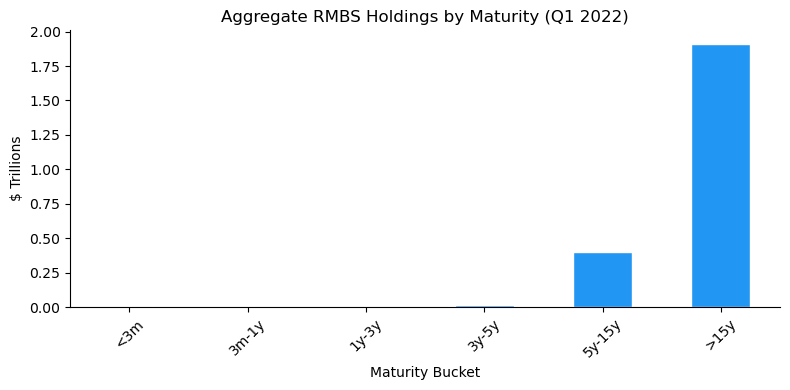

In [7]:
bucket_totals = rmbs[buckets].fillna(0).sum() / 1e9
fig, ax = plt.subplots(figsize=(8, 4))
bucket_totals.plot(kind="bar", ax=ax, color="#2196F3", edgecolor="white")
ax.set_xlabel("Maturity Bucket")
ax.set_ylabel("$ Trillions")
ax.set_title("Aggregate RMBS Holdings by Maturity (Q1 2022)")
ax.tick_params(axis="x", rotation=45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rmbs_by_maturity.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. ETF Price Data

iShares Treasury ETFs by maturity and the iShares MBS ETF are used to
compute mark-to-market price changes from Q1 2022 to Q1 2023.

In [8]:
etf_raw = pull_etf_data.load_etf_data()
print(f"ETF prices: {len(etf_raw)} daily rows, {REPORT_DATE} to {MTM_END_DATE}")
print(f"Columns: {list(etf_raw.columns)}")
etf_raw.tail()

ETF prices: 439 daily rows, 2022-03-31 to 2023-03-31
Columns: ['SP Treasury Index', 'iShares 7-10', 'sp 3-5', 'MBS ETF', 'iShares 0-1', 'iShares 1-3', 'iShares 10-20', 'iShares 20+']


Ticker,SP Treasury Index,iShares 7-10,sp 3-5,MBS ETF,iShares 0-1,iShares 1-3,iShares 10-20,iShares 20+
date,,,,,,,,
2023-09-25,20.316118,83.824303,104.184883,80.577484,98.465973,73.571640,89.439735,80.379074
2023-09-26,20.306913,83.796906,104.166473,80.496117,98.474915,73.580742,89.196342,80.099655
2023-09-27,20.251656,83.422371,103.899269,80.016983,98.492729,73.526161,88.655357,79.685066
2023-09-28,20.297703,83.650742,104.212517,80.496117,98.537331,73.653542,88.862717,79.928421
2023-09-29,20.297703,83.668991,104.267807,80.279152,98.537331,73.662636,88.781609,79.937431


In [9]:
etf_q = clean_data.clean_etf_prices(etf_raw, REPORT_DATE, MTM_END_DATE)
print("Quarterly ETF prices:")
etf_q

Quarterly ETF prices:


Ticker,SP Treasury Index,iShares 7-10,sp 3-5,MBS ETF,iShares 0-1,iShares 1-3,iShares 10-20,iShares 20+
date,,,,,,,,
2022-03-31,23.342937,100.300667,114.823547,92.546997,94.262909,75.329338,124.955383,124.404259
2022-06-30,22.158161,94.172470,108.954002,87.952339,94.116028,73.374741,115.883308,114.613365
2022-09-30,21.563824,91.525169,108.232780,85.529182,94.096352,73.381958,104.769135,100.824478
2022-12-31,20.604691,86.411926,103.854935,80.963867,94.355843,72.155701,96.086449,90.959160
2023-03-31,20.680782,86.571747,104.649162,82.399956,95.179482,72.553726,96.690735,89.529915


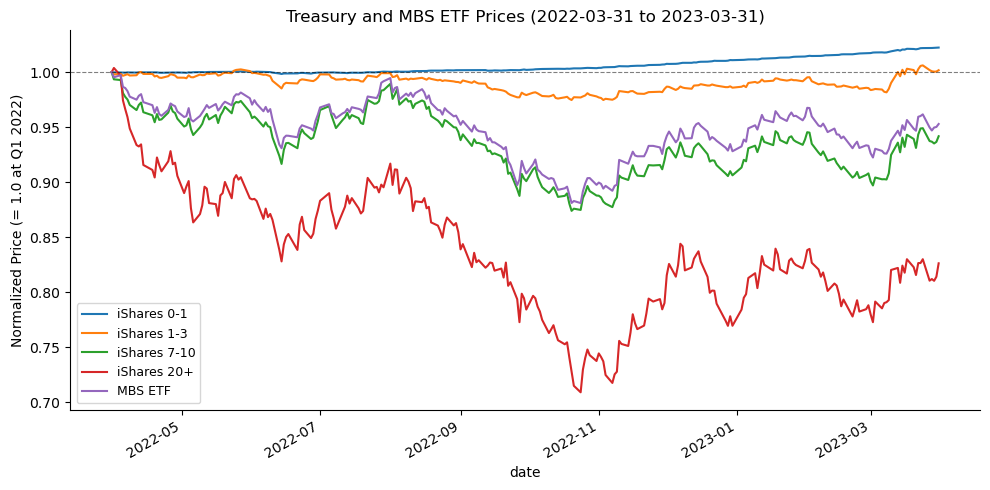

In [10]:
# Plot ETF price changes normalized to 1.0 at REPORT_DATE
etf_norm = etf_raw.loc[REPORT_DATE:MTM_END_DATE].copy()
etf_norm = etf_norm / etf_norm.iloc[0]

fig, ax = plt.subplots(figsize=(10, 5))
for col in ["iShares 0-1", "iShares 1-3", "iShares 7-10", "iShares 20+", "MBS ETF"]:
    etf_norm[col].plot(ax=ax, label=col)
ax.axhline(1.0, color="k", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_ylabel("Normalized Price (= 1.0 at Q1 2022)")
ax.set_title(f"Treasury and MBS ETF Prices ({REPORT_DATE} to {MTM_END_DATE})")
ax.legend(loc="lower left", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "etf_prices.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
price_changes = calc_mtm_losses.calc_price_changes(etf_q, REPORT_DATE, MTM_END_DATE)
rmbs_multiplier = calc_mtm_losses.calc_rmbs_multiplier(etf_q, REPORT_DATE, MTM_END_DATE)

print(f"RMBS multiplier: {rmbs_multiplier:.4f}")
print("\nPrice changes by maturity bucket:")
for bucket, chg in price_changes.items():
    print(f"  {bucket:10s}: {chg*100:+.2f}%")

RMBS multiplier: 0.9614

Price changes by maturity bucket:
  <3m       : +0.97%
  3m-1y     : +0.97%
  1y-3y     : -3.68%
  3y-5y     : -8.86%
  5y-15y    : -13.69%
  >15y      : -28.03%
